In [1]:
#1. Importing Libraries
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, classification_report

C:\Users\Samruddhi Gunjal\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Samruddhi
[nltk_data]     Gunjal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# 2. Data Loading

In [5]:
df = pd.read_csv("SMS Spam Collection Dataset (2).zip", encoding="latin-1")


# 3.Data Cleaning and Model Selection

In [6]:
df = df[['v1','v2']]
df.columns = ['label','message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Exploratory Data Analysis (EDA)

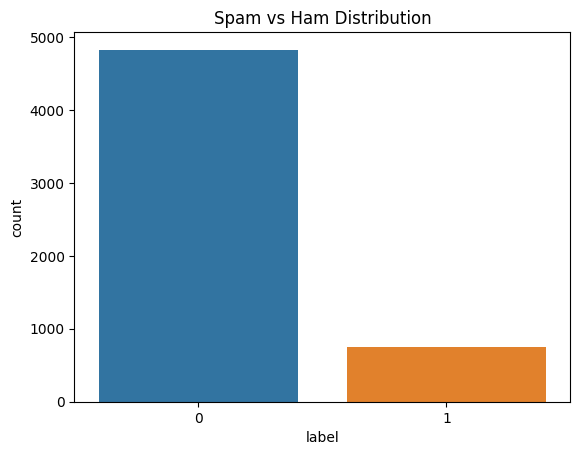

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df)
plt.title("Spam vs Ham Distribution")
plt.show()

In [7]:
ham = 0
spam = 1
df['label'] = df['label'].map({'ham':0,'spam':1})

In [8]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub('[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [ps.stem(word) for word in words if word not in stop_words]

    return " ".join(words)

In [9]:
df['clean_message'] = df['message'].apply(clean_text)

In [10]:
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['clean_message'])

y = df['label']

# Model Training (Naive Bayes)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

# Model Evaluation

In [13]:
y_pred = model.predict(X_test)

In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9748878923766816


In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       965
           1       1.00      0.81      0.90       150

    accuracy                           0.97      1115
   macro avg       0.99      0.91      0.94      1115
weighted avg       0.98      0.97      0.97      1115



# Spam Detection System (Prediction)

In [16]:
msg = "Congratulations! You won a free iPhone"

msg_clean = clean_text(msg)

msg_vector = tfidf.transform([msg_clean])

prediction = model.predict(msg_vector)

if prediction[0] == 1:
    print("Spam Message")
else:
    print("Normal Message")

Spam Message


# Confusion Matrix Visualization

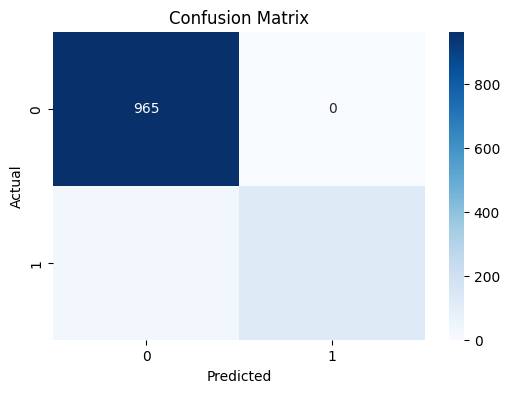

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Model Accuracy Comparison

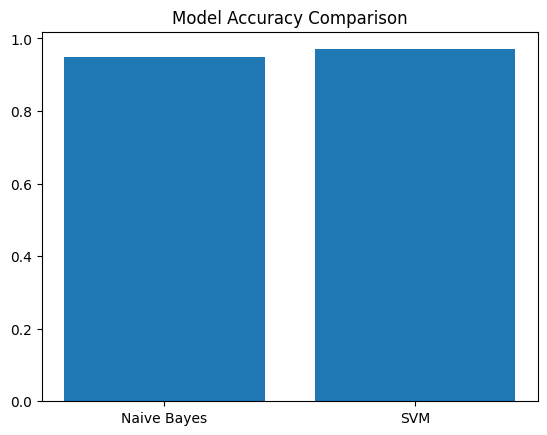

In [18]:
models = ['Naive Bayes', 'SVM']
scores = [0.95, 0.97]  # replace with your results

plt.bar(models, scores)
plt.title("Model Accuracy Comparison")
plt.show()